## Basic Setup

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from keras.models import Sequential, Model
from keras.optimizers import SGD
from keras.applications import MobileNetV2
from keras.regularizers import l2

os.chdir('../../../') # move three level up to the base path
from src.utils import load_and_preprocess_images, plot_history, plot_images, plot_predictions

In [ ]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [ ]:
model_name = '1_synthetic_eyes'
transfer_learning_stage = '1_full_network'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

syntheticDataPath = repo_path + '/data/Unity_Data_Test_Train'
syntheticTrainingPath = syntheticDataPath + '/TrainingSet'
syntheticTestPath = syntheticDataPath + '/TestSet'

realDataPath = repo_path + '/data/CEW_Data_Test_Train'
realTrainingPath = realDataPath + '/TrainingSet'
realTestPath = realDataPath + '/TestSet'

In [ ]:
comment = "afternoon run"
model_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/history/{comment}_history.csv"
assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [ ]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

MN_OUTPUT_LAYER = 'block_16_project_BN'
UNFREEZE_FROM_LAYER = 'block_16_project_BN'
DATA_AUG_RATE = 0.1
EPOCHS = 100
REGULARIZATION = 0.01
DROPOUT = 0.3
LEARNING_RATE = 0.0001
LOSS_FUNCTION = 'sparse_categorical_crossentropy'
OPTIMIZER = SGD(learning_rate=LEARNING_RATE)

In [ ]:
real_train_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
real_valid_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
real_test_data = load_and_preprocess_images(realTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

In [ ]:
synth_train_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
synth_valid_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
synth_test_data = load_and_preprocess_images(syntheticTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

## Finetuning the Pre-Trained Model

In [ ]:
# Custom Finetuning Hyperparameters
FT_EPOCHS = 20
FT_LEARNING_RATE = 0.00001
OPTIMIZER = SGD(learning_rate=FT_LEARNING_RATE)

In [ ]:
# define the path to the pretrained model
pretrained_model_path = repo_path + 'models/cnn/1_synthetic_eyes/0_last_layers/weights/afternoon run_model.keras'

# load the model
pretrained_model = tf.keras.models.load_model(pretrained_model_path, compile=False)

# unfreeze all layers which are not BN layers
for layer in pretrained_model.layers:
    if isinstance(layer, BatchNormalization): # freeze BN layers
        layer.trainable = False
    else: # unfreeze all other layers
        layer.trainable = True

Model: "1_pretrain_cnn"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2     │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1 (Conv2D)    │ (None, 112,     │       864 │ input_layer_2… │   N   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ bn_Conv1          │ (None, 112,     │       128 │ Conv1[0][0]    │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1_relu (ReLU) │ (None, 112,     │         0 │ bn_Conv1[0][0] │   -   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       288 │ Conv1_relu[0]… │   N   │
│ (DepthwiseConv2D) │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       128 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │         0 │ expanded_conv… │   -   │
│ (ReLU)            │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │       512 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │        64 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand    │ (None, 112,     │     1,536 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_BN │ (None, 112,     │       384 │ block_1_expan… │   N   │
│ (BatchNormalizat… │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_r… │ (None, 112,     │         0 │ block_1_expan… │   -   │
│ (ReLU)            │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_pad       │ (None, 113,     │         0 │ block_1_expan… │   -   │
│ (ZeroPadding2D)   │ 113, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwise │ (None, 56, 56,  │       864 │ block_1_pad[0… │   N   │
│ (DepthwiseConv2D) │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │       384 │ block_1_depth… │   N   │
│ (BatchNormalizat… │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │         0 │ block_1_depth… │   -   │
│ (ReLU)            │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_project   │ (None, 56, 56,  │     2,304 │ block_1_depth… │   N 

 Total params: 5,892,292 (22.48 MB)

 Trainable params: 5,650,306 (21.55 MB)

 Non-trainable params: 241,984 (945.25 KB)

 Optimizer params: 2 (12.00 B)

In [ ]:
# compile the model with the same optimizer and loss function
pretrained_model.compile(loss=LOSS_FUNCTION, optimizer=OPTIMIZER, metrics=['accuracy'])

# train the entire model with the same data but lower learning rate
history = pretrained_model.fit(
    synth_train_data,
    validation_data=synth_valid_data,
    epochs=FT_EPOCHS,
    callbacks=[early_stop, reduce_lr] # removed the checkpoint for now
    )

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9379 - loss: 6.8209 - val_accuracy: 0.9346 - val_loss: 6.8701 - learning_rate: 1.0000e-05
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.9461 - loss: 6.8113 - val_accuracy: 0.9335 - val_loss: 6.8664 - learning_rate: 1.0000e-05
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.9409 - loss: 6.8114 - val_accuracy: 0.9325 - val_loss: 6.8788 - learning_rate: 1.0000e-05
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9448 - loss: 6.8185 - val_accuracy: 0.9325 - val_loss: 6.8701 - learning_rate: 1.0000e-05
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9336 - loss: 6.8266 - val_accuracy: 0.9346 - val_loss: 6.8633 - learning_rate: 1.0000e-05
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9410 - loss: 6.8128 - val_accuracy: 0.9314 - val_loss: 6.8623 - learning_rate: 1.0000e-05
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.9385 

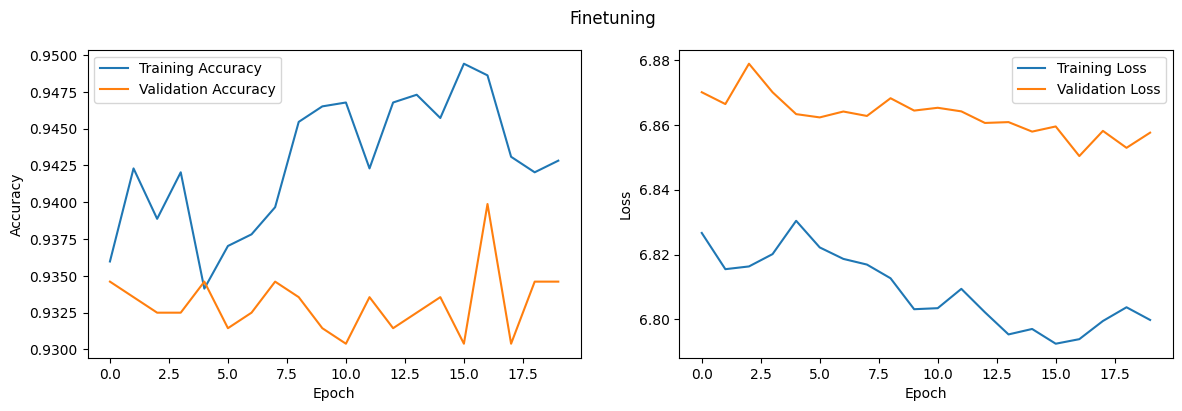

Best train_accuracy: 0.9494
Best train_loss: 6.7925
Best val_accuracy: 0.9399
Best val_loss: 6.8504
Last improvement at epoch: 17


In [ ]:
plot_history("Finetuning", history)

In [ ]:
# evaluate the model
loss, accuracy = pretrained_model.evaluate(synth_test_data)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 562ms/step - accuracy: 0.9494 - loss: 6.8016
Test loss: 6.874223709106445
Test accuracy: 0.930918276309967
